# Methods Figures

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
resultsDir = '/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Results/Group'
saveDir = '/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Presentations/Methods Figures'

statsDF = pd.read_csv(os.path.join(resultsDir, 'SpikeStats.csv'), index_col = 0)
allSpikeInfo = pd.read_csv(os.path.join(resultsDir, 'AllSpikeInfo.csv'), index_col = 0)

## Example Permutation Test
UIC20231401, mLOFC6-2

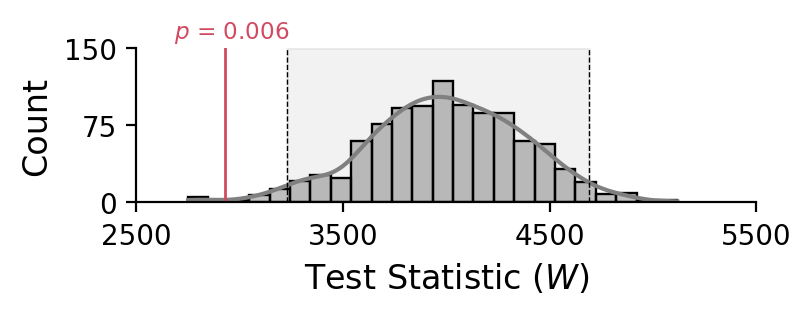

In [8]:
# Get sample unit
sampleInfo = allSpikeInfo[allSpikeInfo['Unit'] == 'mLOFC6-2'].copy()
sample = statsDF[statsDF['Unit'] == 'mLOFC6-2'].copy()
permStats = sample['PermStats'].values[0]
stat = sample['Stat'].values[0]
pVal = sample['pVal'].values[0]

# Convert permStats to list
permStats = permStats[1:-1]
permStats = permStats.split(', ')
permStats = [float(i) for i in permStats]
permStats = np.array(permStats)

# Create figure
fig, ax = plt.subplots(1, 1, figsize = (4, 1))
plotPal = ['#e6e6e6', sns.color_palette('flare')[2]]
sns.histplot(permStats, color = 'grey', ax = ax, kde = True, label = None)
ax.axvline(stat, color = plotPal[1], linestyle = '-', lw = 1, label = None)
ax.axvline(np.quantile(permStats, .025), color = 'k', linestyle = '--', lw = 0.5, label = None)
ax.axvline(np.quantile(permStats, .975), color = 'k', linestyle = '--', lw = 0.5, label = None)
ax.axvspan(np.quantile(permStats, .025), np.quantile(permStats, .975), color = 'grey', alpha = 0.1, zorder = -1, label = None)
ax.text(stat - 250, 160, f'$p$ = {pVal:.3f}', fontsize = 'small', color = plotPal[1])

# Figure aeshtetics
ax.set_xlabel('Test Statistic ($W$)', fontsize = 'large')
ax.set_ylabel('Count', fontsize = 'large')
ax.set_ylim(0, 150)
ax.set_yticks([0, 75, 150])
ax.set_xlim(2500, 5500)
ax.set_xticks([2500, 3500, 4500, 5500])
sns.despine(top = True, right = True)

# Export & Display
plt.savefig((os.path.join(saveDir, 'PermSigEx.png')), dpi = 1200, bbox_inches = 'tight')
plt.show()

## ???